# Import

In [ ]:
import numpy as np
import astropy
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import QTable
from astropy.io import ascii
import glob
import astropy.units as u

# Simulation: Oscillation Model

Data Simulation Team's mess to deal with

In [48]:
class power_spectrum:
    
    
    def __init__(self,star_mass, star_radius, star_teff, sun_granulation_tau, sun_granulation_sigma,  sun_facule_tau = 1, sun_facule_sigma = 1, v_nq = 25):
        """
        Intalises the class, calculates paramters which are always used 

        Parameters
        ----------
        star_mass : int
            mass of star in solar masses .
        star_radius : int
            radius of star in solar radii.
        star_teff : int
            effective temperautre of star in kelvin.
        sun_granulation_tau : int
            characteristic time scale of granulation, or just get the first background component for the sun. In seconds
        sun_granulation_sigma : int
            rms ampltiude of granulation, or just get the first background component for the sun. in ppm 
        sun_facule_tau : int, optional
           characteristic time scale of facule, or just get the second background component for the sun. In seconds. 
            The default is 1.
        sun_facule_sigma : int, optional
            rms ampltiude of facule, or just get the second background component for the sun . in ppm 
            . The default is 1.
        v_nq : int, optional
            Nyquist frequency of the simulated observation. The default is 1.
            Calculated outside of the class as a constant.
            Telescope / camera dependent 

        Returns
        -------
        None.

        """
        
        #sun constants
        
        self.sun_nu_max = 3090 #nu max of sun
        self.sun_teff = 5770
        
        self.sun_granulation_tau = float(sun_granulation_tau)
        self.sun_granulation_sigma = float(sun_granulation_sigma)
        
        self.sun_facule_tau = float(sun_facule_tau)
        self.sun_facule_sigma = float(sun_facule_sigma)
        
        self.v_nq = float(v_nq) #nyquist frequency in seconds 
        
        
        #self.sun_supergranulation_tau = float(sun_supergranulation_tau) #default value is best i could find from research: https://ui.adsabs.harvard.edu/abs/2018LRSP...15....6R/abstract#:~:text=Rieutord%2C%20Michel-,Abstract,a%20selection%20of%20recent%20findings. <-- see chapter about timescales
        #self.sun_supergranulation_sigma = float(sun_supergranulation_sigma) #same again, different source: https://www.researchgate.net/profile/P-Palle/publication/234514213_A_measurement_of_the_background_solar_velocity_spectrum/links/00b495177361416eba000000/A-measurement-of-the-background-solar-velocity-spectrum.pdf
        
        self.sun_max_rms_amplitude = 2.1  
        
        
        
        #line space constants
        
        self.freq_powerspectrum_uHz = np.linspace(0.1, 100000, 50000) #range of frequencies where power spectrum is evaluated
        self.angular_degree = np.linspace(0,3,4) #List of angular degrees l for oscillations :: FOR TESTING I HAVE REDUCED THIS TO 0
        self.radial_mode = np.linspace(0,30,31) #list of radial modes n for oscillations
        
        self.visibilites = [1, 1.505, 0.620, 0.075] # from Ball et al (2018)
        
        
        
        #star properties 
        
        #change to be input from catalogue when class is called
        #self.star_name = star_name #commented this out because it was throwing errors and is never used as far as i can see
        self.star_mass = float(star_mass)
        self.star_radius =  float(star_radius)
        self.star_teff = float(star_teff)
        
        
        #calculatuting star properties
        
        self.nyquist = self.calc_nyquist_term()
        
        self.nu_max_ratio = self.calc_nu_max_ratio() #vmax ratio 
        self.star_nu_max = self.nu_max_ratio * self.sun_nu_max # vmax of star 
        
        self.luminosity_ratio = self.calc_luminosity_ratio() #ratio of star luminosity to sun
        
        self.tau_ratio = self.calc_tau_ratio() #granulation time scale         
        self.sigma_ratio = self.calc_sigma_ratio()
        
        #self.star_property_list = [[self.sun_granulation_sigma, self.sun_granulation_tau],[self.sun_facule_sigma, self.sun_facule_tau],[self.sun_supergranulation_sigma, self.sun_supergranulation_tau]]
        
        #oscillation stuff
        self.sun_delta_nu = 135.1
        self.epsilon= 1.55
        
        self.star_delta_nu = self.sun_delta_nu * (self.star_mass**0.5) * (self.star_radius**(-1.5))
        
        self.max_rms_amplitude_radial_ratio = self.calc_maximum_rms_amplitude_radial_ratio()
        self.star_max_rms_amplitude_radial = self.max_rms_amplitude_radial_ratio *  self.sun_max_rms_amplitude
        
        self.star_standev_envelop = self.calc_envelope_width()
        
        
        #line width constants from paper
        
        #self.alpha = self.calc_width_parameter(2.95, 0.39)
        #self.width_alpha = self.calc_width_parameter(3.08, 3.32)
        #self.delta_width_dip = self.calc_width_parameter(-0.47, 0.62)
        #self.W_dip = self.calc_width_parameter(4637, -141)
        #self.nu_dip = self.calc_width_parameter(2984, 60)
        self.alpha = self.calc_width_parameter(-3.71, 1.073e-3, 1.883e-4)
        self.width_alpha = self.calc_width_parameter(-7.209e1, 1.543e-2, 9.101e-4)
        self.delta_width_dip = self.calc_width_parameter(-2.266e-1, 5.083e-5, 2.715e-6)
        self.W_dip = self.calc_width_parameter(-5.639e-1, 1.138e-4, 1.312e-4)
        self.nu_dip = self.calc_width_parameter(-2.19e3, 4.302e-1, 8.427e-1)
        
        
    #Background models wrapper functions
        
    def theoretical_sigma_tau(self, model = "karoff"):
        """
        Compares the different models of granulation for a sigma, tau etc caluclated using theoreitcal scaling relationships

        Parameters
        ----------
        model : string, optional
            Decides on which model is used. The default is "karoff".
            "karoff" refers to model described in C. Karoff 2013, the first two terms of equation 2
            "ball" refers to the model described in Warrick H. Ball 2018, equation 23 
            "Kallinger" refers to the model described in Kallinger et al: The connection between stellar granulation and oscillations. Equaation 2 model F, sumation terms only 

        Returns
        -------
        granulation_component : array
            The component of the background spectrum due to granulation.
        facule_component : array
            The component of the backgroudn spectrum due to facule.

        """
        
        
        
        if model == "karoff":
            
            star_granulation_tau = self.tau_ratio * self.sun_granulation_tau
            star_granulation_sigma = self.sigma_ratio * self.sun_granulation_sigma
            
            star_facule_sigma = self.sigma_ratio * self.sun_facule_sigma
            star_facule_tau = self.tau_ratio * self.sun_facule_tau
            
            
            
            print("Theory calculated values")
            print(f"star granulation sigma {star_granulation_sigma}, star granulation tau {star_granulation_tau}")        
            print(f"star facule sigma {star_facule_sigma}, star facule tau {star_facule_tau}") 
            
            granulation_component, facule_component = self.calc_karoff_granulation_facule_model(star_granulation_sigma, star_granulation_tau, star_facule_sigma, star_facule_tau)
        
        elif model == 'ball':
            
            star_granulation_tau = self.tau_ratio * self.sun_granulation_tau
            star_granulation_sigma = self.sigma_ratio * self.sun_granulation_sigma
            
            
            granulation_component =  self.calc_granulation_psd_ball(star_granulation_sigma, star_granulation_tau)
            facule_component = 0 #measure to get code to run, unsure if correct
            
        elif model == "Kallinger":
            
            a,  b_1, b_2 = self.calc_scaling_values_kalinger() #calculates sigma, tau for both components of kallinger model using scaling relationships
                
            granulation_component, facule_component = self.calc_kallinger_model(a, b_1, b_2) * (self.nyquist)**2
            
            
        else:
            
            granulation_component, facule_component = self.multi_component(star_granulation_sigma, star_granulation_tau, star_facule_sigma, star_facule_tau)


        #granulation_component = granulation_component * self.nyquist      
        #facule_component = facule_component * self.nyquist

    
        return granulation_component, facule_component
    
    
    def model_comparison(self):
        """
        

        Returns
        -------
        model_1_granulation_component : TYPE
            DESCRIPTION.
        model_1_facule_component : TYPE
            DESCRIPTION.
        star_granulation_sigma_1 : TYPE
            DESCRIPTION.
        star_granulation_tau_1 : TYPE
            DESCRIPTION.
        star_facule_tau_1 : TYPE
            DESCRIPTION.
        model_2_granulation_component : TYPE
            DESCRIPTION.
        model_2_facule_component : TYPE
            DESCRIPTION.
        star_granulation_sigma_2 : TYPE
            DESCRIPTION.
        star_facule_sigma_2 : TYPE
            DESCRIPTION.
        star_granulation_tau_1 : TYPE
            DESCRIPTION.
        star_facule_tau_1 : TYPE
            DESCRIPTION.

        """
        
        a,  b_1, b_2 = self.calc_scaling_values_kalinger() #calculates sigma, tau for both components of kallinger model using scaling relationships    
        
        model_1_granulation_component, model_1_facule_component =  self.calc_kallinger_model(a, b_1, b_2)
        
        star_granulation_sigma_1 = a
        star_facule_sigma_1 = a
        
        star_granulation_tau_1 = 1 / (2 * np.pi * b_1)
        star_facule_tau_1 = 1 / (2 * np.pi * b_2)

        
        
        star_granulation_tau_2 = self.tau_ratio * self.sun_granulation_tau
        star_granulation_sigma_2 = self.sigma_ratio * self.sun_granulation_sigma
        
        star_facule_sigma_2 = self.sigma_ratio * self.sun_facule_sigma
        star_facule_tau_2 = self.tau_ratio * self.sun_facule_tau
        
        model_2_granulation_component, model_2_facule_component =  self.calc_karoff_granulation_facule_model(star_granulation_sigma_2, star_granulation_tau_2, star_facule_sigma_2, star_facule_tau_2)
        
        
        return model_1_granulation_component, model_1_facule_component, star_granulation_sigma_1, star_granulation_tau_1, star_facule_tau_1, model_2_granulation_component, model_2_facule_component,  star_granulation_sigma_2, star_facule_sigma_2, star_granulation_tau_1, star_facule_tau_1

        
            
            
        
        
    def defined_sigma_tau(self, star_granulation_sigma, star_granulation_tau, star_facule_sigma = 1, star_facule_tau = 1, model = "karoff"):
        """
        Compares the different models of granulation for a sigma, tau etc  using given values. Ie from a paper / test values
        
        Note that not all models acount for facule.

        Parameters
        ----------
        star_granulation_sigma : float
            sigma of granulation of the star.
        star_granulation_tau : float
            tau tiem scale of granulation of the star.
        star_facule_sigma : float, optional
            sigma of facule of the star. The default is 1.
        star_facule_tau : float, optional
            DESCRIPTION. The default is 1.
        model : string, optional
            Decides on which model is used. The default is "karoff".
            "karoff" refers to model described in C. Karoff 2013, the first two terms of equation 2
            "ball" refers to the model described in Warrick H. Ball 2018, equation 23 


        Returns
        -------
        granulation_component : array
            The component of the background spectrum due to granulation.
        facule_component : array
            The component of the backgroudn spectrum due to facule.


        """
        
        
        
        if model == "karoff":
            
            print("Practical defiend values ")
            print(f"star granulation sigma {star_granulation_sigma}, star granulation tau {star_granulation_tau}")        
            print(f"star facule sigma {star_facule_sigma}, star facule tau {star_facule_tau}") 
            
            granulation_component, facule_component = self.calc_karoff_granulation_facule_model(star_granulation_sigma, star_granulation_tau, star_facule_sigma, star_facule_tau)
            
        
        elif model == "ball":
            
            granulation_component, facule_component = self.calc_granulation_psd_ball(star_granulation_sigma, star_granulation_tau)
        
        else:
            
            granulation_component, facule_component = self.multi_component(star_granulation_sigma, star_granulation_tau, star_facule_sigma, star_facule_tau)
        
            
        
        return granulation_component, facule_component
        


        
        
    def multi_component(self, star_granulation_sigma, star_granulation_tau, star_facule_sigma, star_facule_tau):
        """
        Models the background due to granulation and facule as two components that take an identical form. One from granulation, one from facule
        Not used, just an escape function for model selection 

        Returns
        -------
        total_background : array
            Total backgorund pSD due to all background components
        facule_component : array
            facule component of background PSD
            

        """
       
        
      
        
        granulation_component = self.calc_component_psd( star_granulation_sigma, star_granulation_tau)
        
        facule_component = self.calc_component_psd( star_facule_sigma, star_facule_tau)
        
        
        return  granulation_component, facule_component
    
    def multi_component_scalable(self):
        """
        Not used atm 
        multi_component but via for loop. 
        

        Returns
        -------
        total_background : array
            Total backgorund pSD due to all background components

        """       
        
        mylist = []
        
        for i in self.star_property_list:
            background_component = self.calc_component_psd(i[0] * self.sigma_ratio, i[1] * self.tau_ratio)
            mylist.append(background_component)
        
        return mylist
    
    #Different background models
    
    def calc_nyquist_term(self):
        """
        Calculates the nyquist frequency term from kallinger paper equation 1. 
        Is the η term in equation 2. 

        Returns
        -------
        nyquist : array
            Value of nyquist equation at each frequency in lin space .

        """
        
        x = self.freq_powerspectrum_uHz * (np.pi / (2*self.v_nq))
        
        nyquist = np.sinc(x / np.pi) #unnormalised sinc function, according to np documentation
        #nyquist = np.sinc(x) #normalised sinc function, apparently the correct one. Maybe not?
        
        return nyquist
        
        
        
    
    
    def calc_kallinger_model(self, a, b_1, b_2):
        """
        Kallinger 2014 model of background granulation / other stuff. Equation 2 model f. Two loretnz functions with a fixed power of 4, with two seperate sigmas, taus etc
        
            
        P(v) = xi * (a^2 / b_1 ) / (1 + (v/b_1)^4) + xi * (a^2 / b_2 ) / (1 + (v/b_2)^4)
        
        granulation_component refers to the first term above. Facule is the 2nd term. 
        
        ai = rms amplitude (sigma) of ith component
        bi = (1 / 2 pi tau), tau = characteristic timescale 
            
            
            
            


        Returns
        -------
        granulation_component : array
            The component of the background spectrum due to granulation.
        facule_component : array
            The component of the backgroudn spectrum due to facule.

        """
        
        freq_uHz = np.asarray(self.freq_powerspectrum_uHz)
        #freq_Hz = freq_uHz * 1e-6
        
        xi = 2 * np.sqrt(2) / np.pi#normalisation factor, defined in paper 
        
        granulation_component = (xi * ((a**2)/b_1))/ (1 + (freq_uHz / b_1)**4)
        facule_component = (xi * ((a**2)/b_2))/ (1 + (freq_uHz / b_2)**4)
        
        return granulation_component, facule_component
        
        
    
    def calc_karoff_granulation_facule_model(self,  star_granulation_sigma, star_granulation_tau, star_facule_sigma, star_facule_tau):
        """
        Granulation and facule model according to Karoff 2013

        Parameters
        ----------
        star_granulation_sigma : TYPE
            DESCRIPTION.
        star_granulation_tau : TYPE
            DESCRIPTION.
        star_facule_sigma : TYPE
            DESCRIPTION.
        star_facule_tau : TYPE
            DESCRIPTION.

        Returns
        -------
        granulation_component : TYPE
            DESCRIPTION.
        facule_component : TYPE
            DESCRIPTION.

        """

         

        
        freq_uHz = np.asarray(self.freq_powerspectrum_uHz)
        freq_Hz = freq_uHz * 1e-6
        
        granulation_component = (3.47 * (star_granulation_sigma**2)*star_granulation_tau)/(1+(2*np.pi*freq_Hz * star_granulation_tau)**3.5)
        facule_component = (6.20 * (star_facule_sigma**2)*star_facule_tau)/(1+(2*np.pi*freq_Hz * star_facule_tau)**6.2)
        
        granulation_component = granulation_component * 1e-6
        facule_component = facule_component * 1e-6
        
        return granulation_component, facule_component
    
    def calc_granulation_psd_ball(self, star_granulation_sigma, star_granulation_tau):
        """
        
        Ball  2018 model fo granulation         
        Calculates power spectrum value at an array of given frequencies using  equation 23 from Ball et al
            P(ν) = 4*sigma^2*tau / (1 + (2πνtau)^2)
            
        Returns array of power spectrum values at each frequency
            
        Has to be done in Hz because the term (2πνtau)^2) needs to be unitless, therefore the frequency needs to be s^-1 to cancel tau s


        Parameters
        ----------
        freq_uHz : array
            Frequency input array in microHz 
        tau_gran_s : float
            Granulation timescale in seconds
        sigma_gran : float
            Granulation amplitude of given star

        Returns
        -------
        psd_per_uHz : array
            power spectrum evaluated at microHz
        """
        freq_uHz = np.asarray(self.freq_powerspectrum_uHz)
        freq_Hz = freq_uHz * 1e-6

        demominator_power  = 4
        
        psd_per_Hz = (4.0 * (star_granulation_sigma ** 2) * star_granulation_tau) / (1.0 + (2.0 * np.pi * freq_Hz * star_granulation_tau) ** demominator_power)
        psd_per_uHz = psd_per_Hz * 1e-6 #converts to uHz 
        return psd_per_uHz
    
    def calc_component_psd(self, star_sigma, star_tau):
        """
        Calculates the power spectrum of one compoment of the background model. 
        The component depends on the variables passed in when the function is called
        ie: facule or granulaion
        
        Calculates power spectrum value at an array of given frequencies using  equation 23 from Ball et al
            P(ν) = 4*sigma^2*tau / (1 + (2πνtau)^2)
            
        Returns array of power spectrum values at each frequency
            
        Has to be done in Hz because the term (2πνtau)^2) needs to be unitless, therefore the frequency needs to be s^-1 to cancel tau s

        Parameters
        ----------
        star_sigma : float
            amplitude of background component.
        star_tau : float
            time scale of background compoment.

        Returns
        -------
        psd_per_uHz : array
            power spectrum evaluated at each frequency for specific background component microHz

        """
        
        freq_uHz = np.asarray(self.freq_powerspectrum_uHz)
        freq_Hz = freq_uHz * 1e-6
        
        demominator_power  = 4

        psd_per_Hz = (4.0 * (star_sigma ** 2) * star_tau) / (1.0 + (2.0 * np.pi * freq_Hz * star_tau) ** demominator_power)

        
        psd_per_uHz = psd_per_Hz * 1e-6
        
        return psd_per_uHz

    #Star properties calculator         
    
    def calc_nu_max_ratio(self):
        """
        Calculate nu_max ratio using scaling relationship

        
        nu_max / nu_max_sun = (M/Msun) * (R/Rsun)^(-2) * (Teff/Teff_sun)^(-1/2)

        Parameters
        ----------
        mass_star : float
            Stellar mass in solar masses
        r_star : float
            Stellar radius in solar radii
        teff_star : float
            Effective temperature in Kelvin

        Returns
        -------
        nu_max : float
            nu_max in microHz
        """
                
        nu_max_ratio =  (self.star_mass / (self.star_radius**2)) * (self.star_teff / self.sun_teff) ** (-0.5)

        return nu_max_ratio
    
    def calc_scaling_values_kalinger(self):
        """
        Calculates the different components of the kalinger model for the given star using the relationships given in table 2
        ai = rms amplitude (sigma) of ith component
        bi = (1 / 2 pi tau), tau = characteristic timescale 
        
        Note with the model, each component isn't specified as being due to facule or granulation. Just keeping with variable naming schemes 
        
        Note the paper says granulation_sigma = facule_sigma and has only 1 rms amplitude
        Scaling relationships as given in kallinger paper table 2

        Returns
        -------
        a : float
            rms amplitude (sigma) of both components.
        b_1 : float
            term related to characteristic timesclale of the first background component. micro sec
        b_2 : float
            term related to characteristic timesclale of the second background component.

        """
        
        
        
        
        #a = 3382 * (self.star_nu_max)**(-0.609) #a == sigma_granulation, without mass term
        #print(f"a without mass {a}")

        a = 3710 * ((self.star_nu_max)**(-0.613)) * ((self.star_mass)**(-0.26)) #with mass term 
        print(f"a with mass {a}")

        b_1 = 0.317 * (self.star_nu_max)**(0.970)
        b_2 = 0.948 * (self.star_nu_max)**(0.992)
        print(f"b_1  {b_1}")
        print(f"b_2  {b_2}")


        
        """
        print("Theory calculated values")
        print(f"star granulation sigma {star_granulation_sigma}, star granulation tau {1 / (2 * np.pi * b_1 * 10**-6)}")        
        print(f"star facule sigma {star_granulation_sigma}, star facule tau {1 / (2 * np.pi * b_2 * 10**-6)}") 
        """
        
        return a, b_1, b_2
        
    def calc_luminosity_ratio(self):
        """
        Compute luminosity ratio L/Lsun using 
       
            L/Lsun = (R/Rsun)^2 * (Teff/Teff_sun)^4

        
        Parameters
        ----------
        
        star_radius : float
            Stellar radius in solar radii
        star_teff : float
            Effective temperature in Kelvin

        Returns
        -------
        luminosity_ratio :float
            Luminosity ratio L/Lsun
        """
        
        luminosity_ratio = (self.star_radius**2) * (self.star_teff / self.sun_teff) ** 4
        
        return luminosity_ratio
    
    def calc_tau_ratio(self):
        """
        Calculate timescale of a background component 
            

    

        Parameters
        ----------
        nu_max_star_uHz : float
            nu_max for the star in microHz

        Returns
        -------
        tau_ratio : float
            time scale ratio of background component
        """
        
        tau_ratio =  (self.nu_max_ratio) ** (-1) #changed ratio

        return tau_ratio
        
    def calc_sigma_ratio(self):
        """
        Calculates amplitude ratio using scaling relationship to remove constants from proportionallity constant. Ball et al equation 22 for proportional relationship for granulation
        

        Scaling relationship of granulation amplitude,
            sigma_star/ sigma_sun =
                (L/Lsun)^2 * (M/Msun)^(-3) * (Teff/Teff_sun)^(-5.5) * (nu_max/nu_max_sun)
                
        

       

        Parameters
        ----------
        nu_max_ratio : float
            Ratio fo nu max of star to sun 
        luminosity_ratio : float
            L/Lsun
        star_mass : float
            Stellar mass in solar masses
        star_teff : float
            Effective temperature in Kelvin
        

        Returns
        -------
        sigma_ratio : float
            ratio of background amplitude in star to sun
        """
        
        

        sigma_ratio = (self.luminosity_ratio ** 2) * (self.star_mass ** -3) * (self.star_teff / self.sun_teff) ** (-5.5) * (self.nu_max_ratio) #changed ratio
        
        

        return sigma_ratio
    
    
        
    
    

    
    #Start of oscillation functions 
    
    def calc_powder_density(self):
        """
        Calculates the power density component due to the oscillations. 
        Main function for oscillations
        

        Returns
        -------
        power_density_oscillations : arrray
            Power spectrum due to oscillations .

        """
        
        #n_min, n_max =  self.calc_n_min_max()
        #n_min_max_linspace = np.linspace(min(n_min), max(n_max), (max(n_max)-min(n_min))+1) #lin space of n values  to itterate  over

        
        power_density_oscillations = np.zeros(len(self.freq_powerspectrum_uHz)) #creates base array same size as frequency array 
        
        for l in self.angular_degree: #itterates over all possible l angular degrees
            
            #self.radial_mode
            for n in self.radial_mode: #itterates over all possible n radial degrees 
            
                #calculates the propeties of the current mode
                nu_nl = self.calc_nu_nl(n,l) 
                width_nl = self.calc_width_nl(n, l)
                nl_rms_amplitude_radial = self.calc_nl_rms_amplitude_radial(nu_nl)
                
                amplitude_nl = self.visibilites[int(l)] * nl_rms_amplitude_radial #scales amplitude of angular mode
                
                power_amplitude = calc_power_amplitude(amplitude_nl, width_nl) #Unscaled height of frequency mode
                lorentz_value = calc_lorentz(self.freq_powerspectrum_uHz, nu_nl, width_nl) #Scaling for the height
                
                power_density_oscillations +=(power_amplitude*lorentz_value) #Scales height of frequency mode using lorentz, then adds to power specturm array
                
        return power_density_oscillations * (self.nyquist)**2 #adds the eta scaling
    
    def calc_nu_nl(self, n,l):
        """
        

        Parameters
        ----------
        n : int
            radial mode
        l : int
            angular degree

        Returns
        -------
        nu_nl : float
            frequency of the p-mode oscillations

        """
        
        #I have no actual idea how D relates to the splitting of the frequencies.
        #I have chucked in the relationship between delta nu_02 and delta nu.
        #In the asymptotic limit, dnu03 = 5/3 dnu02, which i have reflected here (Chaplin and Miglio 2013).
        #I'm gonna die
        
        # linear fit is from the Kepler LEGACY stars scatter plot, with some random Gaussian noise added in (parameters from star data).
        # Keen et al 2014 gives the second term (the frequency splitting term) to be simply the small frequency separation, hence what i have attempted here,
        # though they add it instead of subtracting it, i tested this and it made everything worse, though that may be due to the random element in fit
        
        # fit = (0.05200 * self.star_delta_nu) + np.random.normal(1.42683, 1.41997)
        # fit = (0.05200 * self.star_delta_nu) + 1.42683
        # fit = 3
        fit = 1.0
        # fit = 0
        
        if l % 2 == 0:
        
             nu_nl = self.star_delta_nu * ( n+(l/2) + self.epsilon) - fit * l * (l+1)
            
        elif l % 2 == 1:
            nu_nl = self.star_delta_nu * ( n+(l/2) + self.epsilon) - fit * (5/3) * l * (l+1)
            #nu_nl = self.star_delta_nu * ( n+(l/2) + self.epsilon) - fit * l * (l+1)
        
        return nu_nl
    
    def calc_width_nl(self, n, l):
        """
        Calculates the FWHM of the n, l mode frequency peak 

        Parameters
        ----------
        n : interger
           radial mode.
        l : interger
           angular degree.

        Returns
        -------
        width_nl : float
            Width of the n,l frequency mode.

        """
        
        
        
        
        nu_nl = self.calc_nu_nl(n,l)
        
        line_width = ((self.alpha * np.log(nu_nl / self.star_nu_max)) + np.log(self.width_alpha)) + (np.log(self.delta_width_dip)/(1 + (((2 * np.log(nu_nl/self.nu_dip))/(np.log(self.W_dip/self.star_nu_max)))**2)))
        
        width_nl = np.exp(line_width)
        
        return width_nl
    
    def calc_envelope_width(self):
        """
        Calculates the envelope gaussian width using equation 19 and the line below equation 20 from Ball et al
        
        Envelop = 0.66 * (Vmax)^0.88
        
        Parameters input are in units of microHz hence the conversion terms are removed from the Ball et al equations. 
        

        Returns
        -------
        width_envelope: float.
            FWHM of oscillation envelope

        """
        
        envelope_FWHM = 0.66 * (self.star_nu_max**0.88)
        
        if self.star_teff > self.sun_teff:
            envelope_FWHM = envelope_FWHM * (1+6e-4 * (self.star_teff-self.sun_teff))
            
        width_envelope = envelope_FWHM / (2 * np.sqrt(2*np.log(2)))
 
        return width_envelope

    
                
                
    def calc_dwarf_suppression_beta_term(self):
        """
        Calculates the dwarf suppression term.
        Hot dwarfs have a apparent decrease in amplitude, beta term accounts for that when calculating maximum rms amplitude of all radial modes.

        Returns
        -------
        dwarf_suppression_beta : TYPE
            DESCRIPTION.

        """
        
        power = -0.093
        
        t_red_star = 8907 * self.luminosity_ratio ** power

        
        delta_t = 1250

        dwarf_suppression_beta = 1 - np.exp((self.star_teff - t_red_star)/(delta_t))
        
        return dwarf_suppression_beta

        
                
                
                
    def calc_maximum_rms_amplitude_radial_ratio(self):
        """
        Calculates the maximum rms amplitude of all raidal mode, as a ratio to the suns value using scaling relationships. Ball et all equation 16
        Includes dwarf supression term

        Returns
        -------
        star_max_rms_amplitude_ratio : float
            ratio of the specific stars maximum rms amplitud to the suns .

        """
        
        
        dwarf_suppression_beta = self.calc_dwarf_suppression_beta_term()

        star_max_rms_amplitude_ratio=  dwarf_suppression_beta * self.luminosity_ratio *(self.star_mass**-1) * ((self.star_teff / self.sun_teff) ** (-2))   
        
        return star_max_rms_amplitude_ratio
        
    def calc_nl_rms_amplitude_radial(self, nu_nl):
        """
        Calculates the rms amplitude of the mode that has frequency nu_nl 

        Parameters
        ----------
        nu_nl : float
            frequency of mode with n radial mode and l angular mode.

        Returns
        -------
        star_rms_amplitude : float
            rms amplitude of mode.

        """
        
        
        
        star_rms_amplitude = (((self.star_max_rms_amplitude_radial ** 2) * np.exp(-((nu_nl-self.star_nu_max)**2)/(2*(self.star_standev_envelop**2))))**0.5)
        
        return star_rms_amplitude
        
        
        
    def calc_n_min_max(self):
        """
        Joel code, now defunct
        

        Returns
        -------
        n_min : TYPE
            DESCRIPTION.
        n_max : TYPE
            DESCRIPTION.

        """
        
        n_min = []
        n_max = []
        
        
        
        nu_envelope_min = self.star_nu_max - (3*self.star_standev_envelop)
        nu_envelope_max = self.star_nu_max + (3*self.star_standev_envelop)
        
        for i in self.angular_degree:
            
            n_min.append(int((nu_envelope_min/self.star_delta_nu) - ((i/2) + self.epsilon)))
            n_max.append(int((nu_envelope_max/self.star_delta_nu) - ((i/2) + self.epsilon)))
            
        return n_min, n_max
        
        

        
        
    def calc_width_parameter(self, a, b, c):
        nu_max = self.sun_nu_max * ( self.star_mass/ (self.star_radius**2)) * (self.star_teff / self.sun_teff) ** (-0.5)
        P = a + (b*self.star_teff) + (c*nu_max)
        return P
    
        
    
    

def calc_power_amplitude(amp,width):
    
    # x = (2/np.pi)*((amp**2)/width)
    x = amp
    return x 
        
def calc_lorentz(freq, centroid, FWHM):
    
    x = ((FWHM/2)**2 / ((freq - centroid)**2 + (FWHM/2)**2)) #lorentz curve, !must be multipled by the amplitude!
    return x 


def plot_comparison_model(freq_powerspectrum_uHz, star_name,star_nu_max,  model_1_granulation_component, model_1_facule_component, star_granulation_sigma_1, star_granulation_tau_1, star_facule_tau_1, model_2_granulation_component, model_2_facule_component,  star_granulation_sigma_2, star_facule_sigma_2):
    """
    For comparing two seperate models for two component background models

    Parameters
    ----------
    freq_powerspectrum_uHz : TYPE
        DESCRIPTION.
    star_name : TYPE
        DESCRIPTION.
    star_nu_max : TYPE
        DESCRIPTION.
    model_1_granulation_component : TYPE
        DESCRIPTION.
    model_1_facule_component : TYPE
        DESCRIPTION.
    star_granulation_sigma_1 : TYPE
        DESCRIPTION.
    star_granulation_tau_1 : TYPE
        DESCRIPTION.
    star_facule_tau_1 : TYPE
        DESCRIPTION.
    model_2_granulation_component : TYPE
        DESCRIPTION.
    model_2_facule_component : TYPE
        DESCRIPTION.
    star_granulation_sigma_2 : TYPE
        DESCRIPTION.
    star_facule_sigma_2 : TYPE
        DESCRIPTION.

    Returns
    -------
    None.

    """
    
    
    total_background_model_1 = model_1_facule_component + model_1_granulation_component
    total_background_model_2 = model_2_facule_component + model_2_granulation_component


    plt.loglog(freq_powerspectrum_uHz,total_background_model_1 ,  label = 'Model 1 total', color = 'm')
    plt.loglog(freq_powerspectrum_uHz, model_1_granulation_component ,  label = 'Model 1 granulation', ls = '--', color = 'm')
    plt.loglog(freq_powerspectrum_uHz, model_1_facule_component ,  label = 'Model 1 facule', ls = '-.', color = 'm')
    
    plt.loglog(freq_powerspectrum_uHz, model_2_granulation_component ,  label = 'Model 2 granulation', ls = '--', color = 'k')
    plt.loglog(freq_powerspectrum_uHz, model_2_facule_component ,  label = 'Model 2 facule', ls = '-.', color = 'k')
    plt.loglog(freq_powerspectrum_uHz,total_background_model_2 ,  label = 'Model 2 total', color = 'k')
    
    plt.title(f"Star {star_name} power spectrum")

    
    plt.ylabel("PSD (ppm^2 / uHz)")
    plt.xlabel("Frequency (uHz)")
    

    
    plt.ylim(bottom = 0.1)
    plt.xlim(left = 10)
    
    plt.legend(fontsize=9)


    plt.legend()
    plt.show()

def plot_one_component_psd(freq_powerspectrum_uHz,  granulation_component, oscillation_component, star_nu_max, star_name, model):
    """
    Plots models that only have one component

    Parameters
    ----------
    freq_powerspectrum_uHz : TYPE
        DESCRIPTION.
    granulation_component : TYPE
        DESCRIPTION.
    star_nu_max : TYPE
        DESCRIPTION.
    star_name : TYPE
        DESCRIPTION.

    Returns
    -------
    None.

    """
    
    total_component = granulation_component + oscillation_component 
    
    
    
    plt.loglog(freq_powerspectrum_uHz, granulation_component, label='Granulation background component ')
    plt.loglog(freq_powerspectrum_uHz, total_component, label='Total' )
    plt.title(f"{model} of a one component background of star {star_name}")
    plt.xlim(10, 10000)
    plt.ylim(0.1)
    plt.legend()
    plt.show()

def plot_multi_component_psd(freq_powerspectrum_uHz, granulation_component, facule_component, star_nu_max, star_name, v_nq, model):
    """
    Plots two component background only model 

    Returns
    -------
    None.

    """
    total_background = facule_component + granulation_component  #adds both background components
    #total_background = total_background * (star.nyquist**2) #applies eta term (nyquist)
    facule_component = facule_component #* (star.nyquist**2)
    granulation_component = granulation_component #* (star.nyquist**2)
    
    
    #ymax = total_background.max()
    
    plt.figure()    
    plt.loglog(freq_powerspectrum_uHz, total_background, label='Total ')
    plt.loglog(freq_powerspectrum_uHz, facule_component, linestyle = "--", label='Second background component ')
    plt.loglog(freq_powerspectrum_uHz, granulation_component, linestyle = "--", label='First background component ')
    
    plt.title(f"Star {star_name} background power spectrum")
    
    plt.axvline(star_nu_max, linestyle="--", linewidth=1 , color = 'k', label=r"$\nu_{\max}$")
    #plt.axhline(y=ymax, color="m", linestyle="--", linewidth=1)
    plt.axvline(v_nq, label = 'v nq', color = 'r')
    
    #plt.axvline(200, label = '2000 uhz', color = 'k', linewidth = 2)
    
    plt.ylabel("PSD (ppm^2 / uHz)")
    plt.xlabel("Frequency (uHz)")
    
    #plt.loglog(freq_powerspectrum_uHz, (star.nyquist**2), label = 'eta nyquist term')
    
    plt.ylim(bottom = 0.001, top = 100)
    plt.xlim(left = 1, right = 100000)
    
    plt.legend(fontsize=9)

    plt.show()
  
    

    
def plot_two_component_background_with_oscillations(freq_powerspectrum_uHz, granulation_component, facule_component, oscillation_component, star_nu_max, star_name, v_nq, model):
    """
    Plot models.
    for 410A kallinger
    plt.ylim(bottom = 0.1)
    plt.xlim(left = 10)

    """
       
    total_background = facule_component + granulation_component + oscillation_component  #adds both background components and oscillation
    #total_background = total_background * (star.nyquist**2) #applies eta term (nyquist)
    ymax = total_background.max()
    plt.figure()    
    plt.loglog(freq_powerspectrum_uHz, total_background, label='Total ')
    plt.loglog(freq_powerspectrum_uHz, facule_component, linestyle = "--", label='Facule background ')
    plt.loglog(freq_powerspectrum_uHz, granulation_component, linestyle = "--", label='Granulation background ')
    plt.loglog(freq_powerspectrum_uHz, oscillation_component,color="tab:red", lw=0.6, alpha=0.25, label="Oscillation component",zorder=1)    
    plt.title(f"{star_name}")
    plt.axvline(star_nu_max, linestyle="--", linewidth=1 , color = 'k', label=r"$\nu_{\max}$")
    plt.axhline(y=ymax, color="m", linestyle="--", linewidth=1)
    plt.axvline(v_nq, label = 'v nq', color = 'r')
    #plt.axvline(200, label = '2000 uhz', color = 'k', linewidth = 2)
    plt.ylabel("PSD (ppm²/μHz)")
    plt.xlabel("Frequency (μHz)")
    #plt.loglog(freq_powerspectrum_uHz, (star.nyquist**2), label = 'eta nyquist term')
    plt.ylim(bottom = 0.01)
    plt.xlim(left = 100, right = 10000)
    plt.legend(fontsize=9)
    plt.show()
 
    
def plot_oscillation(freq_powerspectrum_uHz,  oscillation_component, star_nu_max, star_name):
    plt.plot(freq_powerspectrum_uHz, oscillation_component, color = "b", label = "p-mode oscillations")
    # plt.axvline(max_freq(test_star.mass_star, test_star.r_star, test_star.teff_star) * 3100, ls='--', color='r', label = "nu_max")
    # plt.axvline(star_nu_max, ls='--', color='r', label = f"nu_max {star_nu_max:.2f}")
    plt.xlim(star_nu_max-600,star_nu_max+600)
    plt.title(f"{star_name} oscillations Power Spectrum")
    plt.xlabel("Frequency /microHertz")
    plt.ylabel("Power /ppm^2 uHz^-1")
    plt.legend(loc = "best", fontsize = 8)
    plt.show()
    
def plot_oscillation_max(freq_powerspectrum_uHz,  oscillation_component, star_nu_max, star_name):
    plt.plot(freq_powerspectrum_uHz, oscillation_component, color = "blue", label = "p-mode oscillations")
    # plt.axvline(max_freq(test_star.mass_star, test_star.r_star, test_star.teff_star) * 3100, ls='--', color='r', label = "nu_max")
    plt.axvline(star_nu_max, ls='--', color='r', label = f"nu_max {star_nu_max:.2f}")
    plt.xlim(star_nu_max-600,star_nu_max+600)
    plt.title(f"{star_name} oscillations Power Spectrum")
    plt.xlabel("Frequency /microHertz")
    plt.ylabel("Power /ppm^2 Hz^-1")
    plt.legend()
    plt.show()

# Simulation: Solar-Like Oscillations

For Data Analysis Team's use 

In [22]:
# open the catalogue file (renamed 'PIC.fits')
with fits.open(f'PIC.fits') as hdul:
    primary = hdul[0]   # save primaryHDU
    bintable = hdul[1]   # save bintableHDU
    fits_head = bintable.header   # data headings
    fits_data = bintable.data   # data
    print(len(fits_data))   # print number of entries

'''
takes each of the columns in the fits file (column name defined by headers 'TTYPEX') as an array, and appends that array
to a 'master array', allowing the data to be displayed as an astropy table object.
all column names taken from and meanings explained in 'LOPS2PIC2.1.0.1_DataDefinitionDocument_PLATO-SSDC-PDC-DD-0003.pdf' on canvas.
'''
# the master array
# each column of the file is an array stored as one item in the master array
columns = [[i for i in range(309787)]]   # the first item is an array of index numbers
for i in range(1,72):   # there are 71 columns total
    columns.append(fits_data[fits_head[f'TTYPE{i}']])   # append each column as an array, to the master array

# create a table object
pic_table = QTable(columns,
           names=('Index','PICid', 'PICname', 'StarName', 'RAdeg', 'eRAdeg', 'DEdeg', 'eDEdeg', 'pmRA', 'epmRA', 'pmDE', 'epmDE', 'pm', 'epm', 'Plx', 'ePlx', 'distance',
            'edistance', 'Glon', 'Glat', 'posEpoch', 'refEpoch', 'posPropFlag', 'PlatoMagNCAM', 'ePlatoMagNCAM', 'PlatoMagFCAMb', 'ePlatoMagFCAMb',
            'PlatoMagFCAMr', 'ePlatoMagFCAMr', 'Gmag', 'eGmag', 'BPmag', 'eBPmag', 'RPmag', 'eRPmag', 'Hpmag', 'eHpmag', 'Ksmag', 'eKsmag', 'AG', 'eAG',
            'AKs', 'eAKs', 'EBPRP', 'eEBPRP', 'extStatus', 'VmagCalculated', 'eVmagCalculated', 'Teff', 'eTeff', 'Radius', 'eRadius', 'Mass', 'eMass',
            'caseFlag', 'PICmainSourceFlagBOL', 'tPICsourceFlagNCAM_BOL', 'fgPICsourceFlag', 'cPICsourceFlag', 'scvPICsourceFlag', 'NSSFlag',
            'qualityFlag', 'tPICplanetFlag', 'fgPICcPICvariabilityFlag', 'targetStatusFlag', 'BOLrandomSysNSRNCAM_T', 'BOLnCameraObsNCAM_T',
            'BOLnCameraSatNCAM_T', 'tPICscientificRanking', 'scvPICscientificRanking', 'scientificPriority', 'scheduledTarget'),
           meta={'name': 'PIC Table'})

# the stellar properties needed
index = pic_table['Index']   # the index in the file column the star is at
name = pic_table['PICname']
mass = pic_table['Mass']   # solar mass
radius = pic_table['Radius']   # solar radius
teff = pic_table['Teff']   # kelvin

309787


In [53]:
# star names from Target Selection
candidates = ['PIC 2915577000081','PIC 2915571000104','PIC 2912861000050','PIC 2908735000056','PIC 2908735000057',
'PIC 2901793000033','PIC 2897612000102','PIC 2893330000017','PIC 2890529000062','PIC 2889072000139',
'PIC 2886168000063','PIC 2886166000078','PIC 2886218000135','PIC 2886191000129','PIC 2883305000009',
'PIC 2880424000123','PIC 2880424000128','PIC 2878914000067','PIC 2878966000167','PIC 2877464000062',
'PIC 2874507000079','PIC 2870094000052','PIC 2868606000109','PIC 2868638000148','PIC 2864154000102',
'PIC 2862637000040','PIC 2861112000105','PIC 2856556000125','PIC 2847353000081','PIC 2844331000233',
'PIC 2841143000066','PIC 2833293000069','PIC 2705309000027']

# extract the indices of all the candidates from the full catalogue
candidate_index = []
for i in index:
    if name[i] in candidates:
        #print(f'{name[i]} | {mass[i]} | {radius[i]} | {teff[i]}')
        candidate_index.append(i)

# check all found (numbers must match):
print(f'{len(name[candidate_index])}={len(candidates)}')

33=33


#0 STAR 42071: PIC 2915577000081
a with mass 35.689988471068226
b_1  459.3755860386022
b_2  1620.362684757662


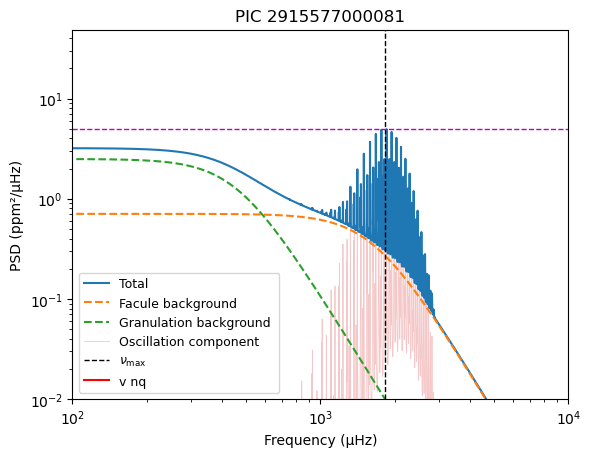

#1 STAR 42124: PIC 2915571000104
a with mass 50.304547127436855
b_1  258.44275770235447
b_2  899.7938944549029


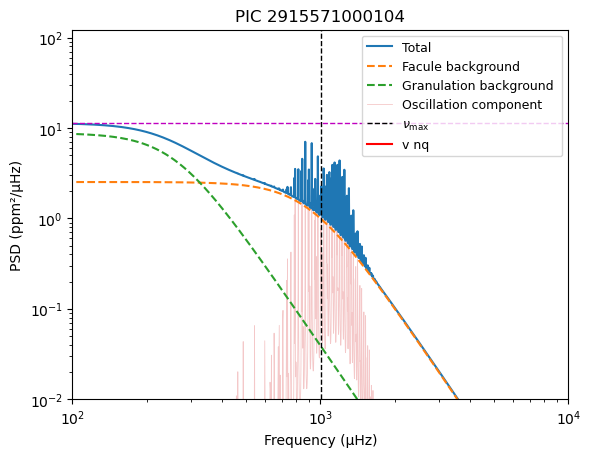

#2 STAR 42763: PIC 2912861000050
a with mass 43.059846659106746
b_1  334.22298169859744
b_2  1170.4362135610381


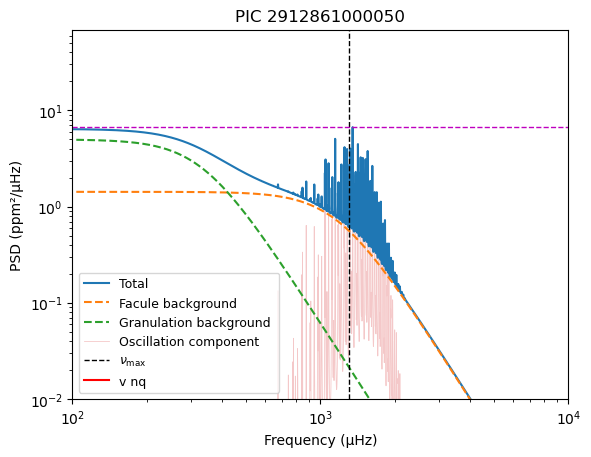

#3 STAR 43913: PIC 2908735000056
a with mass 32.28471646404275
b_1  565.6743357210171
b_2  2004.7539371977462


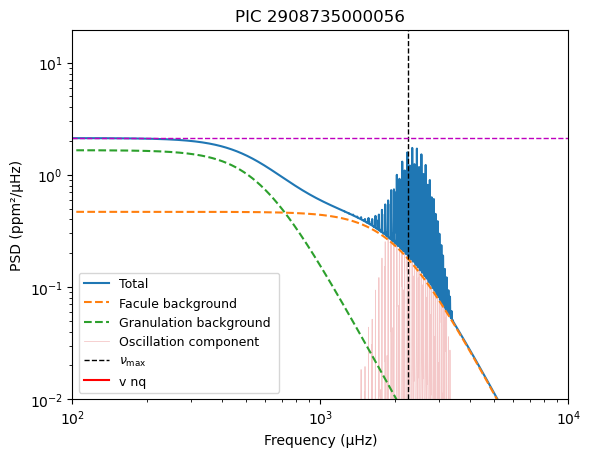

#4 STAR 43914: PIC 2908735000057
a with mass 28.991889410124188
b_1  685.4458724018438
b_2  2439.8294166281407


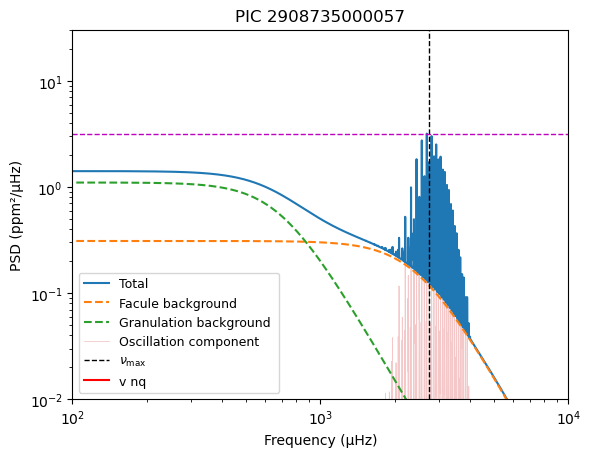

#5 STAR 45845: PIC 2901793000033
a with mass 25.978320281776277
b_1  815.873048883909
b_2  2915.5778679878645


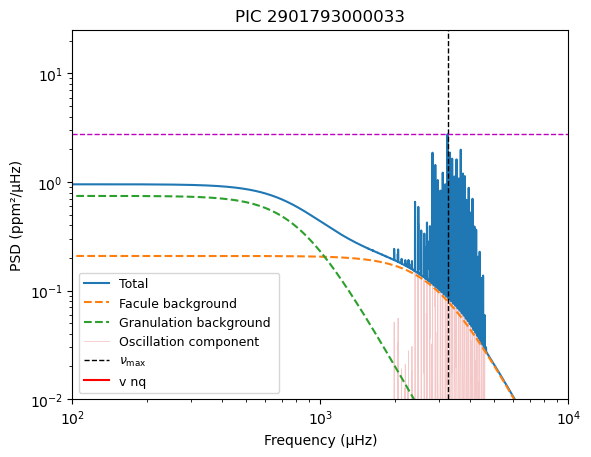

#6 STAR 47119: PIC 2897612000102
a with mass 35.80532512567083
b_1  463.2823605822641
b_2  1634.4570128549067


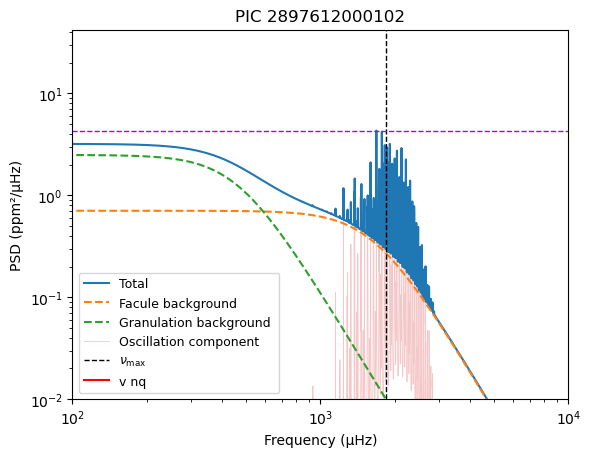

#7 STAR 48065: PIC 2893330000017
a with mass 28.432220605261826
b_1  685.6575438564481
b_2  2440.5999475121434


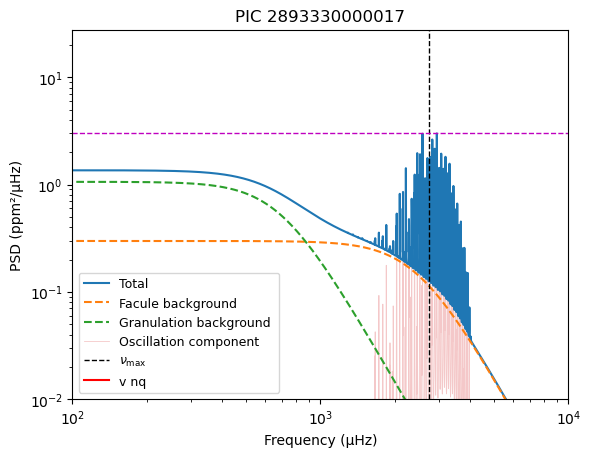

#8 STAR 49007: PIC 2890529000062
a with mass 28.53917748931973
b_1  684.4754086895144
b_2  2436.2967833133876


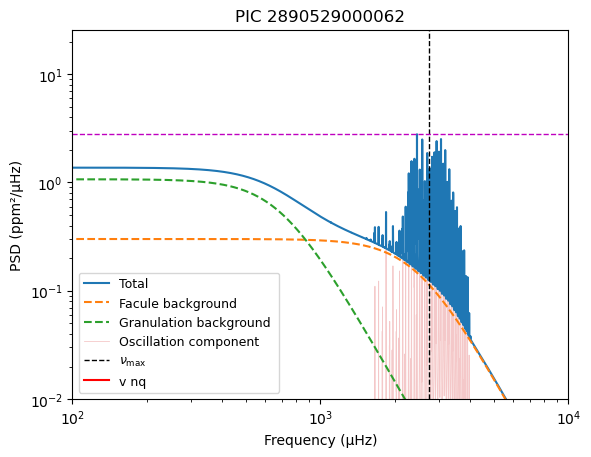

#9 STAR 49788: PIC 2889072000139
a with mass 31.150931447368116
b_1  585.5577998160438
b_2  2076.8477040954376


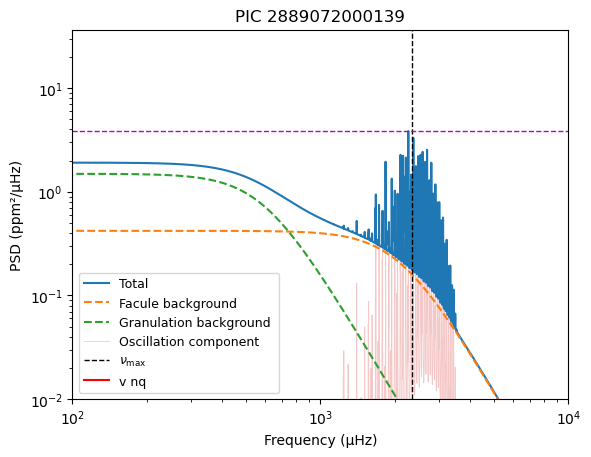

#10 STAR 50315: PIC 2886168000063
a with mass 26.59475975675593
b_1  769.3212631320981
b_2  2745.561058309441


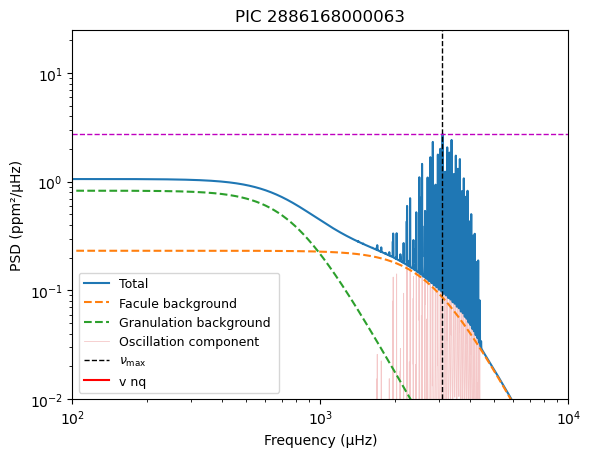

#11 STAR 50413: PIC 2886166000078
a with mass 40.692038266289195
b_1  365.26159829981674
b_2  1281.7112248733342


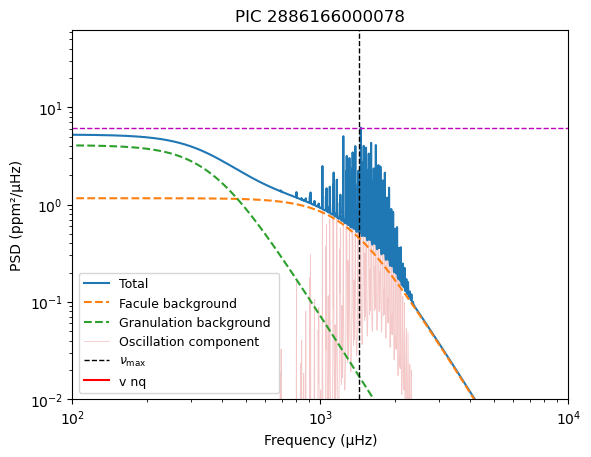

#12 STAR 50421: PIC 2886218000135
a with mass 27.84619671023223
b_1  719.5332760752746
b_2  2563.983537831834


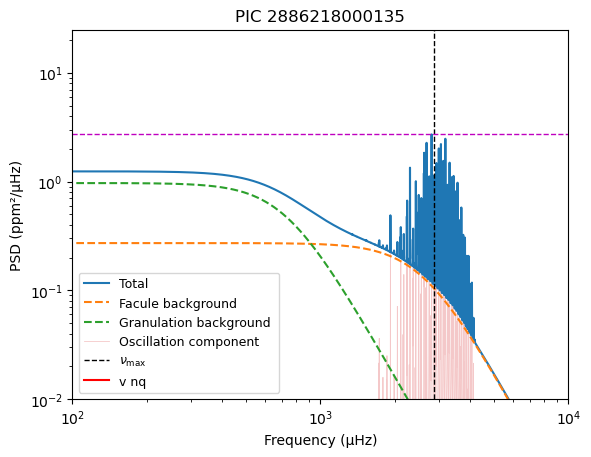

#13 STAR 50479: PIC 2886191000129
a with mass 38.86133493558064
b_1  399.3106526559686
b_2  1404.0253751331245


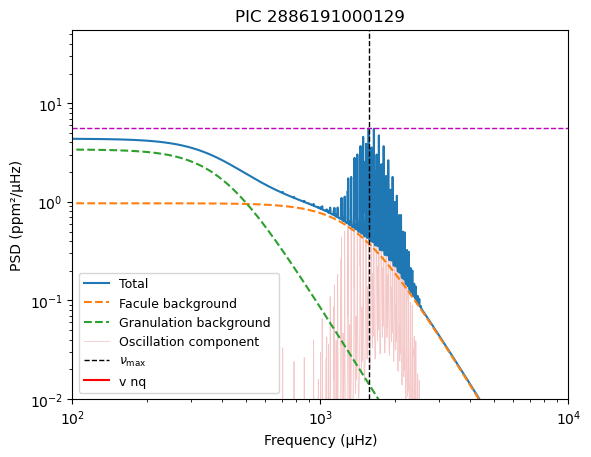

#14 STAR 50798: PIC 2883305000009
a with mass 27.365145589851505
b_1  734.6640563486808
b_2  2619.136451758725


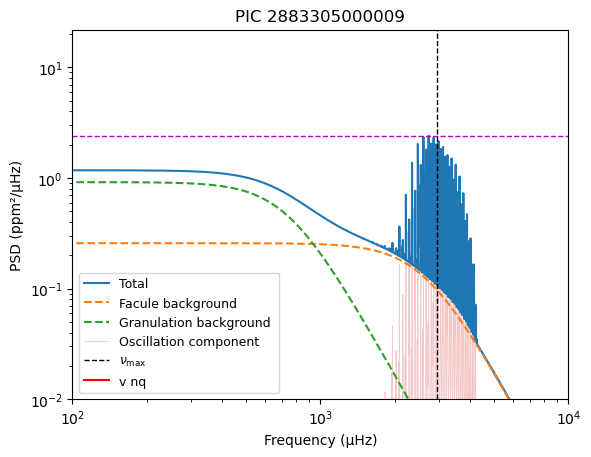

#15 STAR 51995: PIC 2880424000123
a with mass 30.00294257694546
b_1  622.7082993754576
b_2  2211.6960332400718


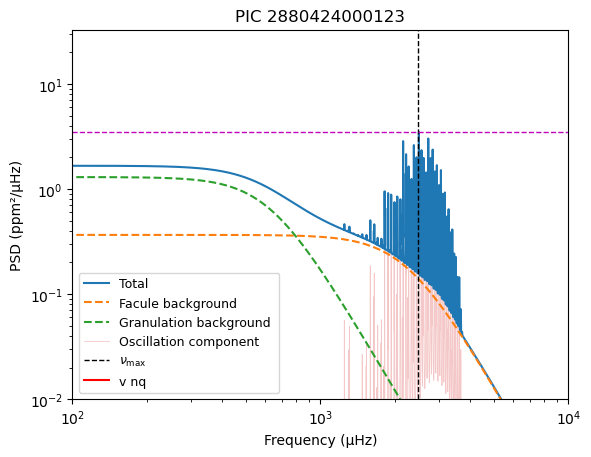

#16 STAR 52007: PIC 2880424000128
a with mass 27.649614104435994
b_1  723.5428383756667
b_2  2578.596176534715


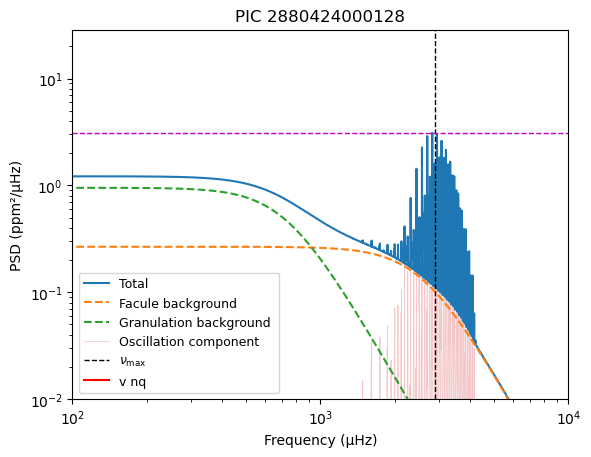

#17 STAR 52302: PIC 2878914000067
a with mass 23.638219800558666
b_1  961.0146981305344
b_2  3447.0281800993757


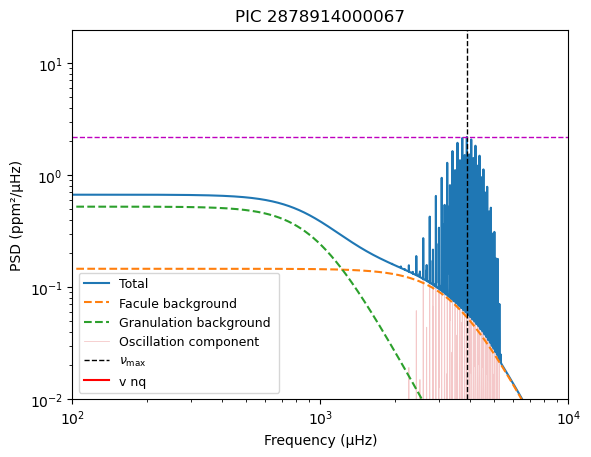

#18 STAR 52549: PIC 2878966000167
a with mass 32.76966373597235
b_1  542.9055794991529
b_2  1922.2693297501598


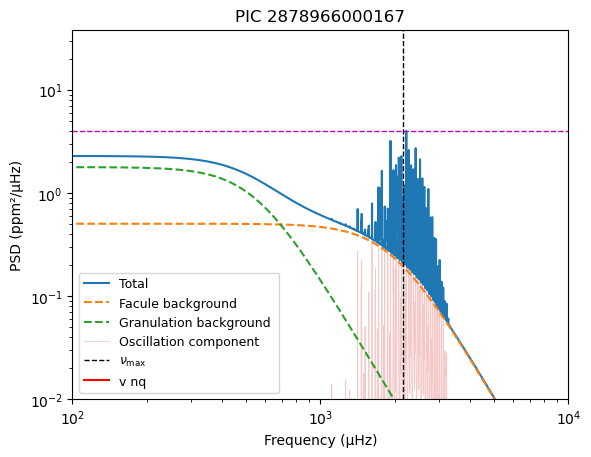

#19 STAR 52704: PIC 2877464000062
a with mass 41.55586525612275
b_1  360.0927323053628
b_2  1263.1651776998888


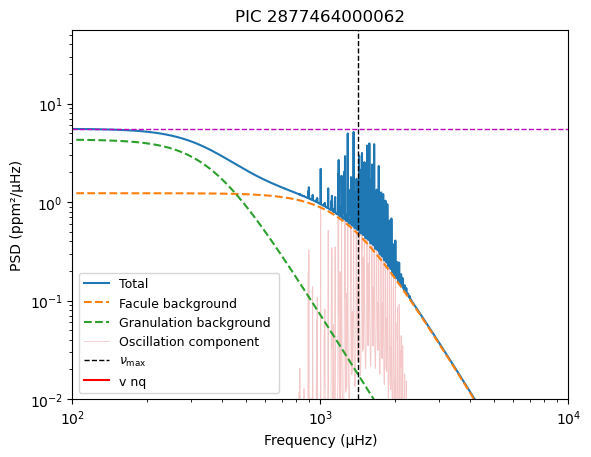

#20 STAR 53703: PIC 2874507000079
a with mass 25.53701778261345
b_1  856.9402007014477
b_2  3065.746921835857


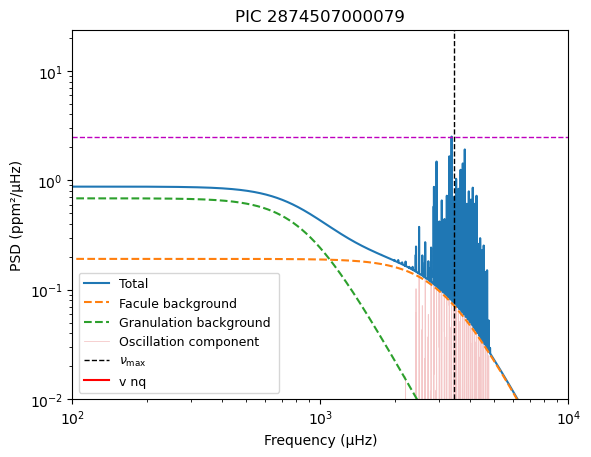

#21 STAR 54794: PIC 2870094000052
a with mass 34.71720257476194
b_1  485.0133482949735
b_2  1712.9037069911917


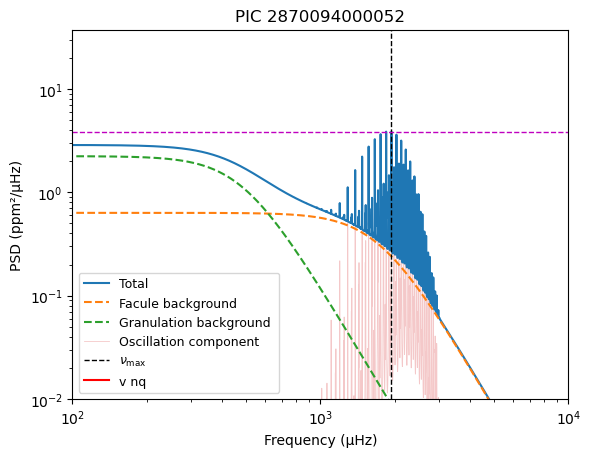

#22 STAR 55374: PIC 2868606000109
a with mass 37.118924472724274
b_1  430.5095906543693
b_2  1516.309669422706


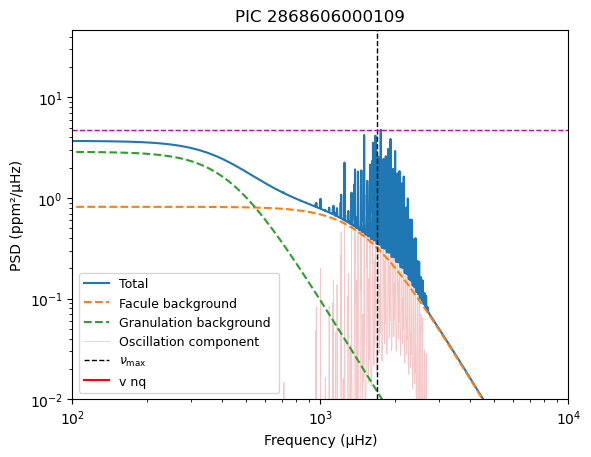

#23 STAR 55387: PIC 2868638000148
a with mass 29.671455947067862
b_1  635.9473990307093
b_2  2259.7958200916883


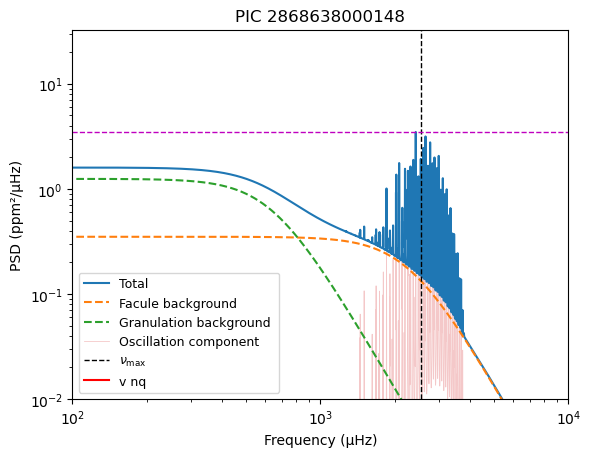

#24 STAR 56464: PIC 2864154000102
a with mass 25.568805726235826
b_1  855.3513037758621
b_2  3059.933761397404


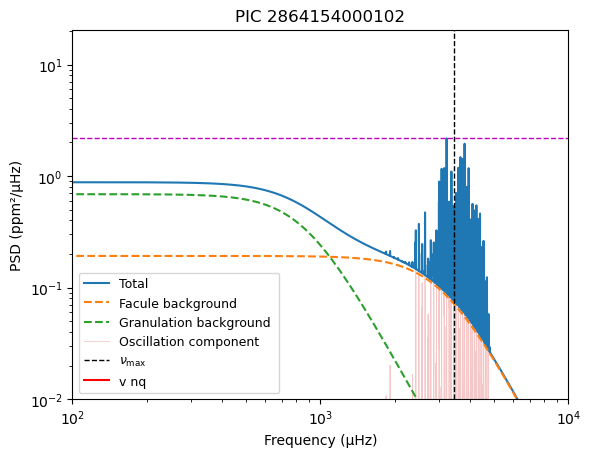

#25 STAR 56742: PIC 2862637000040
a with mass 35.887601588562745
b_1  461.6639894758947
b_2  1628.6181460567693


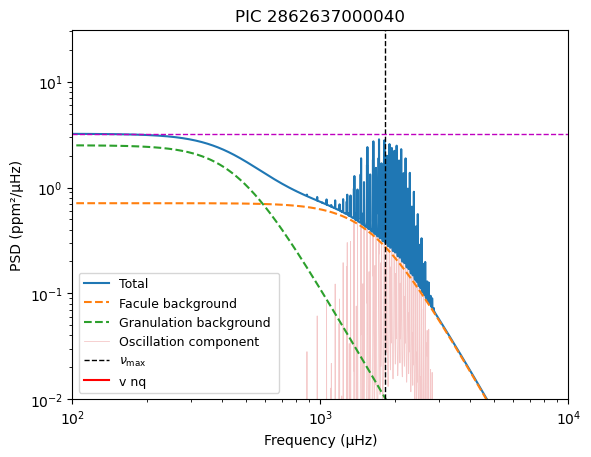

#26 STAR 57351: PIC 2861112000105
a with mass 24.51320041360457
b_1  907.6980079222366
b_2  3251.5764499405427


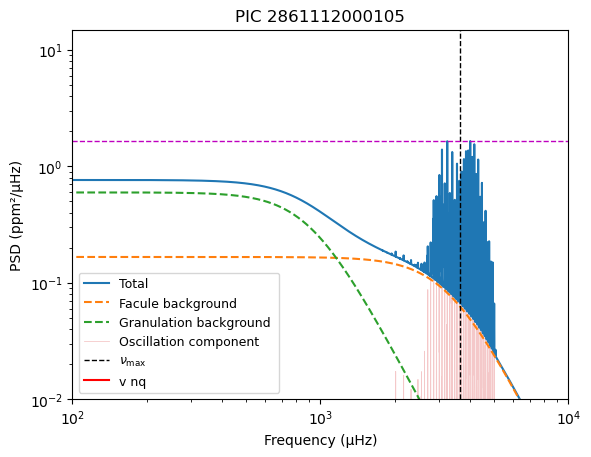

#27 STAR 58737: PIC 2856556000125
a with mass 28.999276100656463
b_1  662.9310330494776
b_2  2357.901572575325


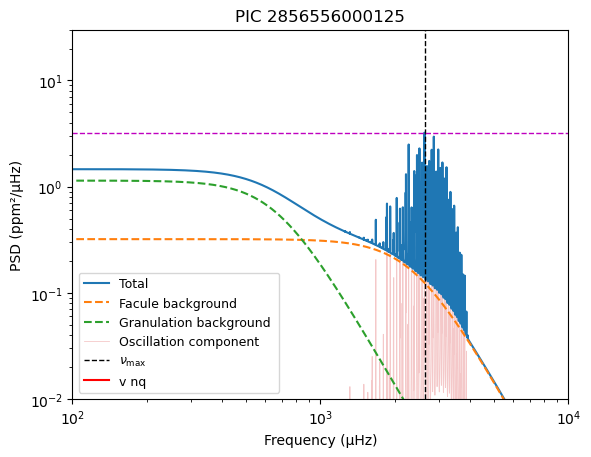

#28 STAR 61100: PIC 2847353000081
a with mass 31.602522442220994
b_1  566.5041897573207
b_2  2007.7616992080605


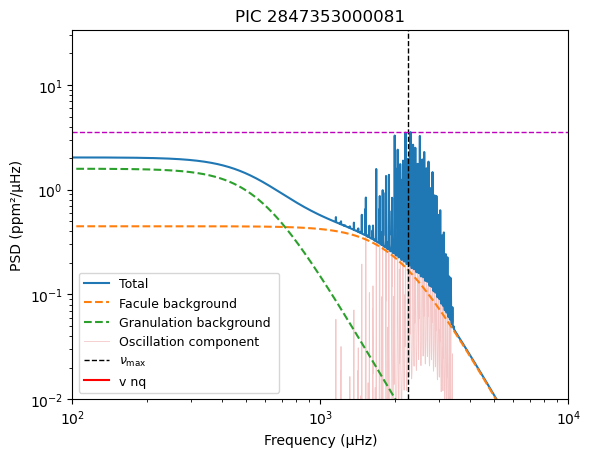

#29 STAR 62090: PIC 2844331000233
a with mass 47.79016853511103
b_1  275.5115358369054
b_2  960.6129148753605


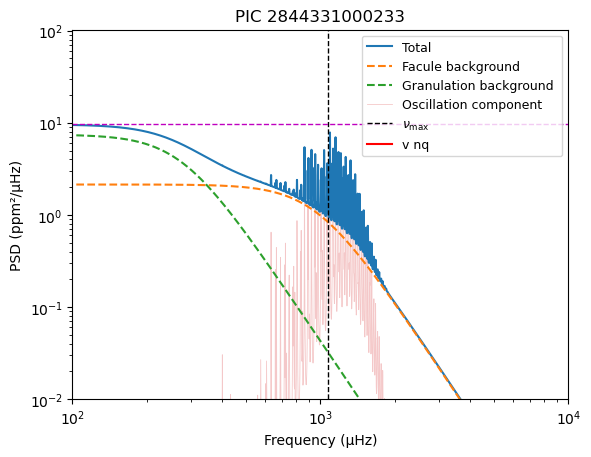

#30 STAR 62641: PIC 2841143000066
a with mass 36.413886058919275
b_1  446.90962963381764
b_2  1575.40799573338


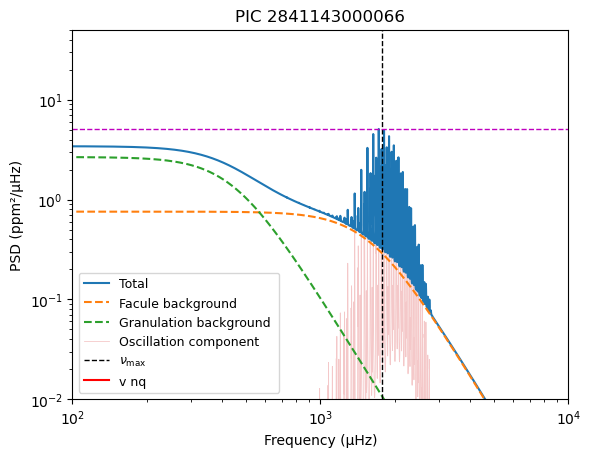

#31 STAR 64743: PIC 2833293000069
a with mass 45.58270635604698
b_1  299.487167379216
b_2  1046.1856390031617


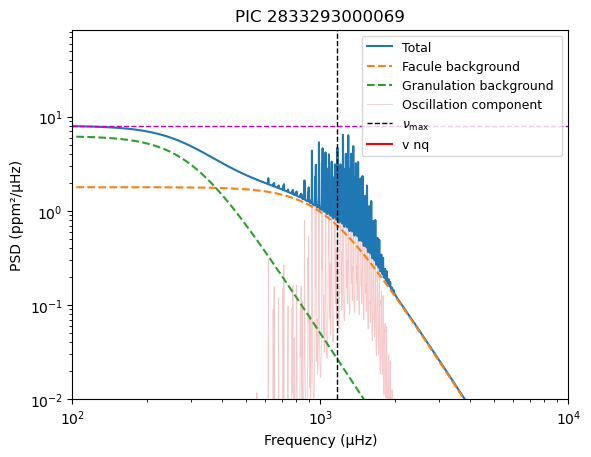

#32 STAR 98184: PIC 2705309000027
a with mass 22.542074377701976
b_1  1066.9997906294348
b_2  3836.2738976193286


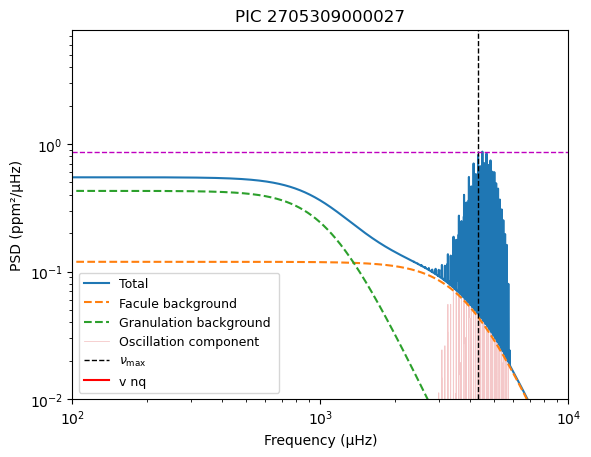

In [51]:
sun_granulation_tau, sun_granulation_sigma = 214, 62.4
cadence = 25 # cadence of pluto in secs
v_nq = 1e6 / (2 * cadence)  # nyquist frequency in micro Hz

count = 0   # keep track of how many of the candidate stars have been plotted
for i in candidate_index:
    print(f'#{count} STAR {i}: {name[i]}')
    star = power_spectrum(mass[i], radius[i], teff[i], sun_granulation_tau, sun_granulation_sigma, v_nq = v_nq)
    granulation_component, facule_component = star.theoretical_sigma_tau(model = "Kallinger")
    oscillation_component = star.calc_powder_density()
    plot_two_component_background_with_oscillations(star.freq_powerspectrum_uHz, granulation_component, facule_component, oscillation_component, star.star_nu_max, name[i], v_nq, model="Kallinger")
    count += 1